# Rare-Event Detection: Flood Mapping from Sentinel-1 SAR Imagery
**Advanced Machine Learning – Mini Project**

**Problem.** Floods are rare events: in satellite imagery, flooded/water pixels are a small minority. A model that predicts "no water" everywhere gets high accuracy but is useless. This project compares methods for handling this imbalance in a semantic segmentation task.

**Data.** Sen1Floods11 (Bonafilia et al., 2020): 446 hand-labeled 512×512 chips from 11 flood events worldwide. Input: Sentinel-1 SAR (VV, VH polarisations, in dB). Radar sees through clouds, which matters because floods happen during storms.

**Experiments.**
1. Otsu thresholding on VV backscatter (classical remote-sensing baseline, no ML)
2. U-Net + plain BCE (no imbalance handling)
3. U-Net + class-weighted BCE
4. U-Net + Focal + Dice loss + oversampling of flood-rich chips

**Evaluation.** IoU, precision, recall, F1 on the water class (plus accuracy, to show why it misleads). Tested on the standard test split and on **Bolivia**, a flood event never seen in training (generalisation test), then applied to the **April 2024 Rufiji floods in Tanzania** as a real-world case study.

**Explainability.** Permutation channel importance and test-time-augmentation uncertainty show what the model relies on and where its flood map can be trusted.

> Runtime → Change runtime type → **T4 GPU** before running.

## 1. Setup and data download

In [1]:
!pip install -q segmentation-models-pytorch rasterio scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.0 MB/s eta 0:00:00


In [2]:
# Sen1Floods11 is in a public Google Cloud bucket. Hand-labeled S1 + labels is ~1 GB.
# If gsutil asks for credentials, run: from google.colab import auth; auth.authenticate_user()
!mkdir -p /content/sen1floods11
!gsutil -m -q cp -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand /content/sen1floods11/
!gsutil -m -q cp -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand /content/sen1floods11/
!gsutil -m -q cp -r gs://sen1floods11/v1.1/splits/flood_handlabeled /content/sen1floods11/
!ls /content/sen1floods11/S1Hand | wc -l; ls /content/sen1floods11/flood_handlabeled

446
flood_bolivia_data.csv	flood_train_data.csv
flood_test_data.csv	flood_valid_data.csv


## 2. Imports and configuration

In [3]:
import os, time, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import rasterio, torch, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import segmentation_models_pytorch as smp
from skimage.filters import threshold_otsu
from sklearn.metrics import precision_recall_curve, auc

ROOT = "/content/sen1floods11"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 40          # ~3-5 min per experiment on a T4
BATCH = 16
CROP = 256
LR = 3e-4
SEED = 42

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()
print("Device:", DEVICE)

Device: cuda


## 3. Load data
Labels: `1` = water, `0` = not water, `-1` = no data / cloud (ignored in loss and metrics).
We use three input channels: VV, VH and VV−VH (the polarisation ratio in dB, which helps separate water from other dark surfaces).

In [4]:
def read_split(name):
    df = pd.read_csv(f"{ROOT}/flood_handlabeled/{name}", header=None)
    return list(zip(df[0], df[1]))

def load_chip(s1_file, lbl_file):
    with rasterio.open(f"{ROOT}/S1Hand/{s1_file}") as f:
        s1 = f.read().astype(np.float32)            # (2, H, W): VV, VH in dB
    with rasterio.open(f"{ROOT}/LabelHand/{lbl_file}") as f:
        y = f.read(1).astype(np.int8)                # (H, W)
    s1 = np.nan_to_num(s1, nan=-50.0)
    s1 = np.clip(s1, -50, 1)
    x = np.concatenate([s1, (s1[0] - s1[1])[None]], axis=0)
    return x, y

def load_split(name):
    pairs = read_split(name)
    X, Y = zip(*[load_chip(a, b) for a, b in pairs])
    return np.stack(X), np.stack(Y)

t0 = time.time()
Xtr, Ytr = load_split("flood_train_data.csv")
Xva, Yva = load_split("flood_valid_data.csv")
Xte, Yte = load_split("flood_test_data.csv")
Xbo, Ybo = load_split("flood_bolivia_data.csv")
print(f"Loaded in {time.time()-t0:.0f}s")
for n, Y in [("train", Ytr), ("val", Yva), ("test", Yte), ("bolivia", Ybo)]:
    print(f"{n:8s} chips={len(Y):4d}")

# Keep raw VV (dB) for the Otsu baseline before normalising
VV_te_raw, VV_bo_raw = Xte[:, 0].copy(), Xbo[:, 0].copy()

# Normalise with training statistics only (no leakage)
MEAN = Xtr.mean(axis=(0, 2, 3), keepdims=True)
STD  = Xtr.std(axis=(0, 2, 3), keepdims=True)
Xtr, Xva, Xte, Xbo = [((X - MEAN) / STD).astype(np.float32) for X in (Xtr, Xva, Xte, Xbo)]

Loaded in 7s
train    chips= 252
val      chips=  89
test     chips=  90
bolivia  chips=  15


## 4. How rare is the event? (class imbalance analysis)

train    water fraction of valid pixels:  9.51%
val      water fraction of valid pixels: 11.03%
test     water fraction of valid pixels: 12.51%
bolivia  water fraction of valid pixels: 15.86%


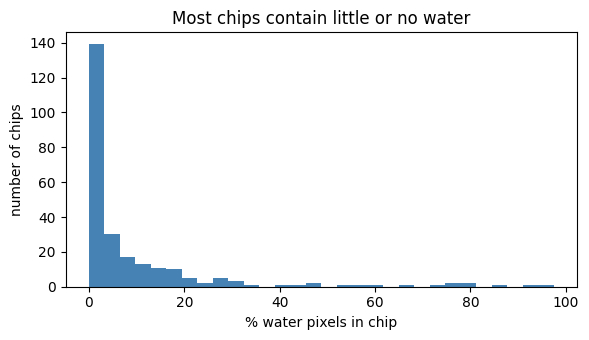

A model predicting 'no water' everywhere would score 90.5% accuracy and 0 IoU.


In [5]:
def water_stats(Y):
    valid = Y != -1
    return (Y == 1).sum() / valid.sum()

for n, Y in [("train", Ytr), ("val", Yva), ("test", Yte), ("bolivia", Ybo)]:
    print(f"{n:8s} water fraction of valid pixels: {water_stats(Y)*100:5.2f}%")

chip_frac = [((y == 1).sum() / max((y != -1).sum(), 1)) for y in Ytr]
plt.figure(figsize=(6, 3.5))
plt.hist(np.array(chip_frac) * 100, bins=30, color="steelblue")
plt.xlabel("% water pixels in chip"); plt.ylabel("number of chips")
plt.title("Most chips contain little or no water"); plt.tight_layout(); plt.show()

p = water_stats(Ytr)
print(f"A model predicting 'no water' everywhere would score {100*(1-p):.1f}% accuracy and 0 IoU.")

## 5. Dataset, augmentation and oversampling

In [6]:
class FloodDS(Dataset):
    def __init__(self, X, Y, train=False):
        self.X, self.Y, self.train = X, Y, train
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x, y = self.X[i], self.Y[i]
        if self.train:
            H, W = y.shape
            r, c = np.random.randint(0, H - CROP + 1), np.random.randint(0, W - CROP + 1)
            x, y = x[:, r:r+CROP, c:c+CROP], y[r:r+CROP, c:c+CROP]
            if np.random.rand() < .5: x, y = x[:, :, ::-1], y[:, ::-1]
            if np.random.rand() < .5: x, y = x[:, ::-1, :], y[::-1, :]
            k = np.random.randint(4); x, y = np.rot90(x, k, (1, 2)), np.rot90(y, k)
        return torch.from_numpy(x.copy()), torch.from_numpy(y.copy()).long()

def make_loader(oversample=False):
    ds = FloodDS(Xtr, Ytr, train=True)
    if oversample:
        # Rare-event oversampling: chips with more water are drawn more often
        w = np.array(chip_frac) + 0.05
        sampler = WeightedRandomSampler(w, num_samples=len(ds), replacement=True)
        return DataLoader(ds, BATCH, sampler=sampler, num_workers=2, drop_last=True)
    return DataLoader(ds, BATCH, shuffle=True, num_workers=2, drop_last=True)

val_loader  = DataLoader(FloodDS(Xva, Yva), 8)
test_loader = DataLoader(FloodDS(Xte, Yte), 8)
bol_loader  = DataLoader(FloodDS(Xbo, Ybo), 8)

## 6. Loss functions for imbalanced segmentation
- **BCE**: standard, treats every pixel equally → dominated by the majority class.
- **Weighted BCE**: multiplies loss on water pixels by `pos_weight = N_neg / N_pos`.
- **Focal loss** (Lin et al., 2017): down-weights easy, confidently-classified pixels so training focuses on hard ones.
- **Dice loss**: directly optimises overlap with the water class, insensitive to how many background pixels there are.

All losses ignore `-1` (no-data) pixels.

In [7]:
def masked_bce(logits, y, pos_weight=None):
    valid, t = y != -1, (y == 1).float()
    loss = F.binary_cross_entropy_with_logits(logits, t, pos_weight=pos_weight, reduction="none")
    return loss[valid].mean()

def focal_loss(logits, y, alpha=0.75, gamma=2.0):
    valid, t = y != -1, (y == 1).float()
    bce = F.binary_cross_entropy_with_logits(logits, t, reduction="none")
    p = torch.sigmoid(logits)
    pt = p * t + (1 - p) * (1 - t)
    a = alpha * t + (1 - alpha) * (1 - t)
    return (a * (1 - pt) ** gamma * bce)[valid].mean()

def dice_loss(logits, y, eps=1.0):
    valid = (y != -1).float()
    t = (y == 1).float() * valid
    p = torch.sigmoid(logits) * valid
    inter = (p * t).sum()
    return 1 - (2 * inter + eps) / (p.sum() + t.sum() + eps)

n_pos = (Ytr == 1).sum(); n_neg = (Ytr == 0).sum()
POS_WEIGHT = torch.tensor(n_neg / n_pos, dtype=torch.float32, device=DEVICE)
print(f"pos_weight = {POS_WEIGHT.item():.1f}")

LOSSES = {
    "bce":          lambda l, y: masked_bce(l, y),
    "weighted_bce": lambda l, y: masked_bce(l, y, POS_WEIGHT),
    "focal_dice":   lambda l, y: focal_loss(l, y) + dice_loss(l, y),
}

pos_weight = 9.5


## 7. Metrics

In [8]:
def confusion(pred, y):
    valid = y != -1
    p, t = pred[valid], y[valid] == 1
    return np.array([(p & t).sum(), (p & ~t).sum(), (~p & t).sum(), (~p & ~t).sum()], dtype=np.int64)

def scores(cm):
    tp, fp, fn, tn = cm
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    return {"IoU": tp / max(tp + fp + fn, 1), "Precision": prec, "Recall": rec,
            "F1": 2 * prec * rec / max(prec + rec, 1e-9), "Accuracy": (tp + tn) / cm.sum()}

@torch.no_grad()
def predict_probs(model, loader):
    model.eval(); out = []
    for x, _ in loader:
        with torch.autocast(DEVICE, enabled=DEVICE == "cuda"):
            out.append(torch.sigmoid(model(x.to(DEVICE)).float()).squeeze(1).cpu().numpy())
    return np.concatenate(out)

def evaluate(model, loader, Y, thr=0.5):
    return scores(confusion(predict_probs(model, loader) > thr, Y))

## 8. Baseline: Otsu thresholding (no machine learning)
Water is a smooth surface that reflects radar away from the sensor, so it appears dark in VV. Otsu picks a per-chip threshold automatically.

In [9]:
def otsu_predict(VV):
    preds = []
    for v in VV:
        vals = v[v > -50]                      # ignore no-data pixels
        if vals.size == 0 or vals.min() == vals.max():
            preds.append(np.zeros_like(v, dtype=bool))   # empty chip: predict no water
            continue
        preds.append(v < threshold_otsu(vals))
    return np.stack(preds)
results = {}
results["Otsu threshold"] = {
    "test": scores(confusion(otsu_predict(VV_te_raw), Yte)),
    "bolivia": scores(confusion(otsu_predict(VV_bo_raw), Ybo)),
}
results["Otsu threshold"]["test"]

{'IoU': np.float64(0.21003564667937824),
 'Precision': np.float64(0.22934269999332704),
 'Recall': np.float64(0.7138729145890984),
 'F1': np.float64(0.3471561309053421),
 'Accuracy': np.float64(0.6641947283001761)}

## 9. Training loop (U-Net, ImageNet-pretrained ResNet-34 encoder)

In [10]:
def train_experiment(name, loss_name, oversample=False, label=None):
    set_seed()
    model = smp.Unet("resnet34", encoder_weights="imagenet", in_channels=3, classes=1).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS)
    scaler = torch.amp.GradScaler("cuda", enabled=DEVICE == "cuda")
    loss_fn, loader = LOSSES[loss_name], make_loader(oversample)
    best_iou, hist, ckpt = -1, [], f"/content/{name}.pt"
    t0 = time.time()
    for ep in range(EPOCHS):
        model.train(); tot = 0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            with torch.autocast(DEVICE, enabled=DEVICE == "cuda"):
                logits = model(x).squeeze(1)
            loss = loss_fn(logits.float(), y)
            opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tot += loss.item()
        sched.step()
        v = evaluate(model, val_loader, Yva)
        hist.append((tot / len(loader), v["IoU"]))
        if v["IoU"] > best_iou:
            best_iou = v["IoU"]; torch.save(model.state_dict(), ckpt)
        if ep % 5 == 0 or ep == EPOCHS - 1:
            print(f"[{name}] ep {ep:2d} loss {tot/len(loader):.4f} val IoU {v['IoU']:.3f}")
    print(f"[{name}] done in {(time.time()-t0)/60:.1f} min, best val IoU {best_iou:.3f}")
    model.load_state_dict(torch.load(ckpt))
    results[label or name] = {"test": evaluate(model, test_loader, Yte),
                     "bolivia": evaluate(model, bol_loader, Ybo), "history": hist}
    return model

## 10. Run the experiments

In [11]:
models = {}
models["U-Net + BCE"] = train_experiment("unet_bce", "bce", label="U-Net + BCE")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

[unet_bce] ep  0 loss 0.6714 val IoU 0.155
[unet_bce] ep  5 loss 0.3002 val IoU 0.479
[unet_bce] ep 10 loss 0.2052 val IoU 0.612
[unet_bce] ep 15 loss 0.1673 val IoU 0.579
[unet_bce] ep 20 loss 0.1685 val IoU 0.606
[unet_bce] ep 25 loss 0.1544 val IoU 0.468
[unet_bce] ep 30 loss 0.1398 val IoU 0.638
[unet_bce] ep 35 loss 0.1331 val IoU 0.628
[unet_bce] ep 39 loss 0.1313 val IoU 0.647
[unet_bce] done in 2.3 min, best val IoU 0.659


In [12]:
models["U-Net + weighted BCE"] = train_experiment("unet_wbce", "weighted_bce", label="U-Net + weighted BCE")

[unet_wbce] ep  0 loss 0.9627 val IoU 0.202
[unet_wbce] ep  5 loss 0.6137 val IoU 0.409
[unet_wbce] ep 10 loss 0.5638 val IoU 0.350
[unet_wbce] ep 15 loss 0.5114 val IoU 0.418
[unet_wbce] ep 20 loss 0.5025 val IoU 0.502
[unet_wbce] ep 25 loss 0.5139 val IoU 0.414
[unet_wbce] ep 30 loss 0.4277 val IoU 0.508
[unet_wbce] ep 35 loss 0.4206 val IoU 0.519
[unet_wbce] ep 39 loss 0.4385 val IoU 0.495
[unet_wbce] done in 2.3 min, best val IoU 0.536


In [13]:
models["U-Net + focal+dice + oversampling"] = train_experiment("unet_focaldice_os", "focal_dice", oversample=True, label="U-Net + focal+dice + oversampling")

[unet_focaldice_os] ep  0 loss 0.4626 val IoU 0.133
[unet_focaldice_os] ep  5 loss 0.2969 val IoU 0.538
[unet_focaldice_os] ep 10 loss 0.2895 val IoU 0.622
[unet_focaldice_os] ep 15 loss 0.2413 val IoU 0.608
[unet_focaldice_os] ep 20 loss 0.2195 val IoU 0.664
[unet_focaldice_os] ep 25 loss 0.2288 val IoU 0.575
[unet_focaldice_os] ep 30 loss 0.1994 val IoU 0.646
[unet_focaldice_os] ep 35 loss 0.1788 val IoU 0.626
[unet_focaldice_os] ep 39 loss 0.2108 val IoU 0.642
[unet_focaldice_os] done in 2.4 min, best val IoU 0.664


## 11. Results

In [14]:
rows = []
for name, r in results.items():
    for split in ("test", "bolivia"):
        rows.append({"Method": name, "Split": split, **{k: round(v, 3) for k, v in r[split].items()}})
table = pd.DataFrame(rows)
display(table.pivot(index="Method", columns="Split", values=["IoU", "Precision", "Recall", "F1", "Accuracy"]))
table.to_csv("/content/results.csv", index=False)

IoU        Precision         Recall  \
Split                             bolivia   test   bolivia   test bolivia   
Method                                                                      
Otsu threshold                      0.340  0.210     0.365  0.229   0.830   
U-Net + BCE                         0.613  0.678     0.787  0.839   0.735   
U-Net + focal+dice + oversampling   0.560  0.676     0.698  0.802   0.740   
U-Net + weighted BCE                0.553  0.595     0.586  0.632   0.907   

                                              F1        Accuracy         
Split                               test bolivia   test  bolivia   test  
Method                                                                   
Otsu threshold                     0.714   0.507  0.347    0.744  0.664  
U-Net + BCE                        0.780   0.760  0.808    0.926  0.954  
U-Net + focal+dice + oversampling  0.812   0.718  0.807    0.908  0.951  
U-Net + weighted BCE               0.911   0.712  0.746    0.883  0.923

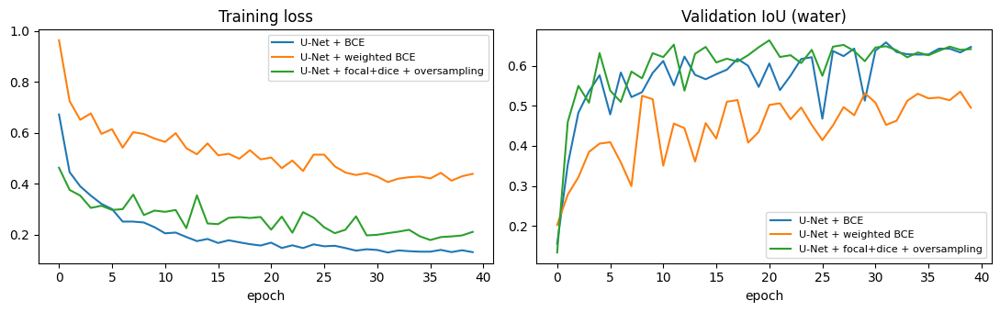

In [15]:
# Learning curves
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for name, r in results.items():
    if "history" in r:
        h = np.array(r["history"])
        ax[0].plot(h[:, 0], label=name); ax[1].plot(h[:, 1], label=name)
ax[0].set_title("Training loss"); ax[1].set_title("Validation IoU (water)")
for a in ax: a.set_xlabel("epoch"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Precision–recall curves (the right curve for rare events)
ROC curves look optimistic when negatives dominate; PR curves show the real trade-off between missed floods and false alarms.

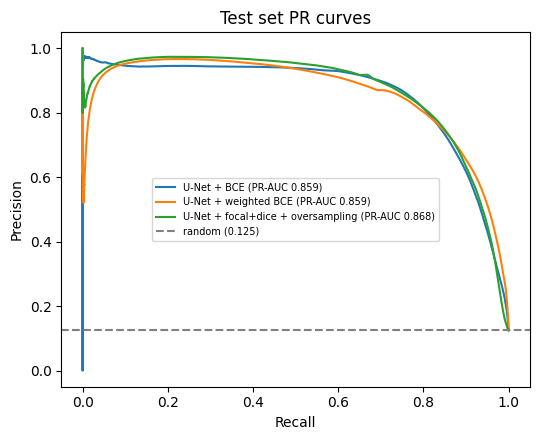

In [16]:
valid = Yte != -1
yt = (Yte[valid] == 1).astype(np.uint8)
idx = np.random.default_rng(0).choice(len(yt), size=min(2_000_000, len(yt)), replace=False)
plt.figure(figsize=(5.5, 4.5))
for name, m in models.items():
    probs = predict_probs(m, test_loader)[valid]
    p, r, _ = precision_recall_curve(yt[idx], probs[idx])
    plt.plot(r, p, label=f"{name} (PR-AUC {auc(r, p):.3f})")
plt.axhline(yt.mean(), ls="--", c="gray", label=f"random ({yt.mean():.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(fontsize=7); plt.title("Test set PR curves")
plt.tight_layout(); plt.show()

## 12. Visual comparison

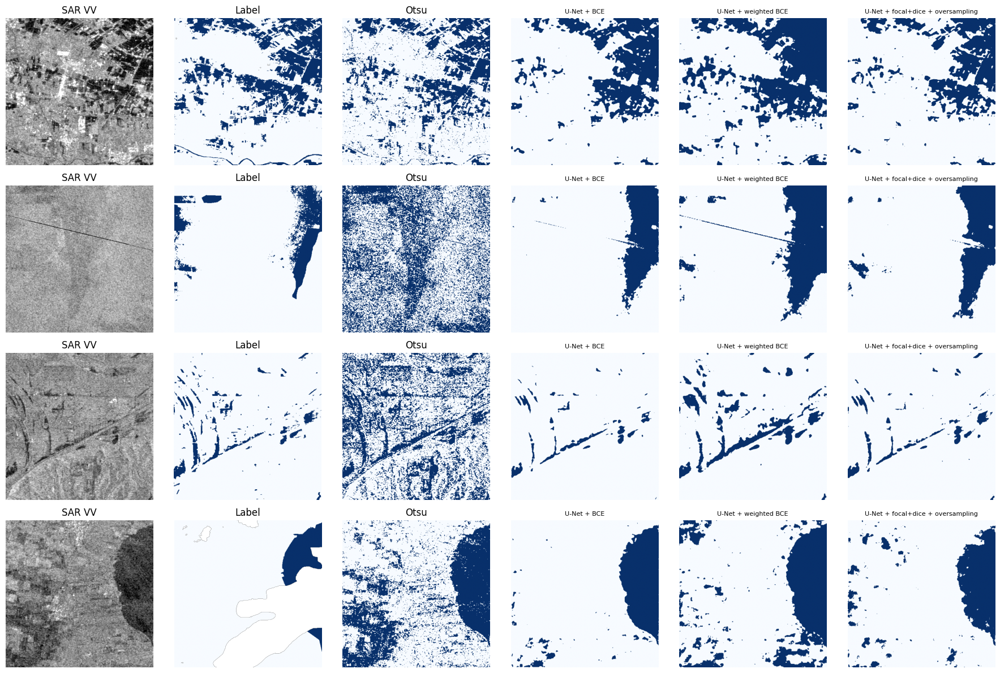

In [17]:
def show_examples(X, Y, VV_raw, n=4, seed=1):
    rng = np.random.default_rng(seed)
    cand = [i for i in range(len(Y)) if (Y[i] == 1).mean() > 0.05]
    ids = rng.choice(cand, size=min(n, len(cand)), replace=False)
    names = list(models)
    fig, ax = plt.subplots(len(ids), 3 + len(names), figsize=(3 * (3 + len(names)), 3 * len(ids)))
    ax = np.atleast_2d(ax)
    for r, i in enumerate(ids):
        x = torch.from_numpy(X[i:i+1]).to(DEVICE)
        ax[r, 0].imshow(VV_raw[i], cmap="gray", vmin=-25, vmax=0); ax[r, 0].set_title("SAR VV")
        ax[r, 1].imshow(np.where(Y[i] == -1, np.nan, Y[i]), cmap="Blues"); ax[r, 1].set_title("Label")
        ax[r, 2].imshow(otsu_predict(VV_raw[i:i+1])[0], cmap="Blues"); ax[r, 2].set_title("Otsu")
        for c, nm in enumerate(names):
            models[nm].eval()
            with torch.no_grad():
                pr = torch.sigmoid(models[nm](x)).squeeze().cpu().numpy() > .5
            ax[r, 3 + c].imshow(pr, cmap="Blues"); ax[r, 3 + c].set_title(nm, fontsize=8)
    for a in ax.ravel(): a.axis("off")
    plt.tight_layout(); plt.show()

show_examples(Xte, Yte, VV_te_raw)

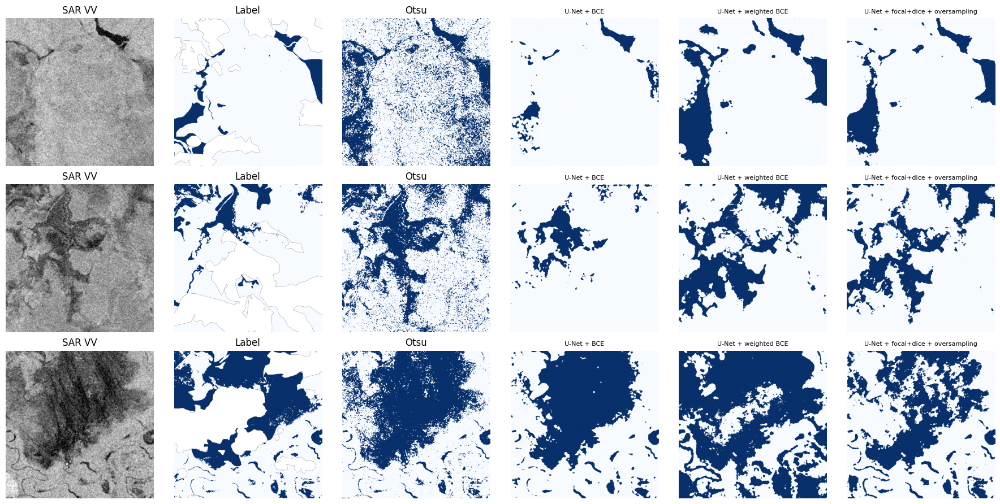

In [18]:
# Generalisation to an unseen flood event
show_examples(Xbo, Ybo, VV_bo_raw, n=3)

## 14. Case study: Rufiji River floods, Tanzania (April 2024)
Sen1Floods11 contains no Tanzanian scenes, so this is a true **out-of-distribution test**: we apply the best model to a real Tanzanian flood.

**Event.** Heavy rains from 7 April 2024 (El Niño + positive Indian Ocean Dipole) flooded Rufiji and Kibiti districts, Pwani Region. The district reported roughly 34,000 ha of crops affected and 88,000 people in need of assistance (ReliefWeb, April 2024).

**Approach (change detection).**
1. Get Sentinel-1 imagery over the lower Rufiji floodplain for the flood period and for a dry-season reference.
2. Run the trained U-Net on both → water maps.
3. **Flooded = water during flood AND NOT water in dry season AND NOT permanent water** (JRC Global Surface Water).
4. Overlay ESA WorldCover to estimate flooded cropland and settlements.

**No ground-truth labels exist for this scene**, so we evaluate by (a) comparing flooded cropland to the officially reported figure, (b) agreement with an independent Otsu change-detection map, and (c) visual inspection.

> **Requires a free Google Earth Engine account** linked to a Google Cloud project (register for non-commercial/academic use at earthengine.google.com). Do this early, since approval is not always instant.

In [19]:
!pip install -q earthengine-api pyproj
import ee, datetime
ee.Authenticate()
ee.Initialize(project="research1-nmaist")   # <-- replace with your Earth Engine cloud project ID

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [20]:
from pyproj import Transformer

# Lower Rufiji floodplain between Utete and Ikwiriri. Adjust the box to study another area.
BBOX = dict(lon_min=38.75, lon_max=39.25, lat_min=-8.10, lat_max=-7.80)
FLOOD_DATES = ("2024-04-05", "2024-05-05")   # 2024 long-rains flood
DRY_DATES   = ("2023-08-01", "2023-10-31")   # dry-season reference
SCALE, CRS, TILE = 10, "EPSG:32737", 512     # 10 m like Sen1Floods11; UTM zone 37S

tf = Transformer.from_crs("EPSG:4326", CRS, always_xy=True)
x_min, y_max = tf.transform(BBOX["lon_min"], BBOX["lat_max"])
x_max, y_min = tf.transform(BBOX["lon_max"], BBOX["lat_min"])
n_cols = int(np.ceil((x_max - x_min) / (TILE * SCALE)))
n_rows = int(np.ceil((y_max - y_min) / (TILE * SCALE)))
print(f"Scene: {n_rows} x {n_cols} tiles of {TILE}px = {n_rows*TILE*SCALE/1000:.0f} x {n_cols*TILE*SCALE/1000:.0f} km")

aoi = ee.Geometry.Rectangle([BBOX["lon_min"], BBOX["lat_min"], BBOX["lon_max"], BBOX["lat_max"]])

def s1_median(start, end):
    col = (ee.ImageCollection("COPERNICUS/S1_GRD").filterBounds(aoi).filterDate(start, end)
           .filter(ee.Filter.eq("instrumentMode", "IW"))
           .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
           .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
           .select(["VV", "VH"]))
    dates = sorted({datetime.datetime.fromtimestamp(t / 1000, datetime.timezone.utc).strftime("%Y-%m-%d")
                    for t in col.aggregate_array("system:time_start").getInfo()})
    print(f"{start} to {end}: {len(dates)} acquisition dates {dates}")
    return col.median()   # median reduces radar speckle

def fetch_grid(image, bands, fill):
    # Download the scene tile by tile (512x512) as numpy arrays
    img = image.select(bands).unmask(fill).toFloat()
    out = np.full((len(bands), n_rows * TILE, n_cols * TILE), fill, np.float32)
    for r in range(n_rows):
        for c in range(n_cols):
            req = {"expression": img, "fileFormat": "NUMPY_NDARRAY",
                   "grid": {"dimensions": {"width": TILE, "height": TILE},
                            "affineTransform": {"scaleX": SCALE, "shearX": 0, "translateX": x_min + c * TILE * SCALE,
                                                "shearY": 0, "scaleY": -SCALE, "translateY": y_max - r * TILE * SCALE},
                            "crsCode": CRS}}
            for attempt in range(3):
                try:
                    arr = ee.data.computePixels(req); break
                except Exception as e:
                    err = e; time.sleep(5)
            else:
                raise err
            for i, b in enumerate(bands):
                out[i, r*TILE:(r+1)*TILE, c*TILE:(c+1)*TILE] = arr[b]
    return out

t0 = time.time()
S1_flood = fetch_grid(s1_median(*FLOOD_DATES), ["VV", "VH"], fill=-50)
S1_dry   = fetch_grid(s1_median(*DRY_DATES),   ["VV", "VH"], fill=-50)
PERM = fetch_grid(ee.Image("JRC/GSW1_4/GlobalSurfaceWater"), ["occurrence"], fill=0)[0] >= 50
WC   = fetch_grid(ee.ImageCollection("ESA/WorldCover/v200").first(), ["Map"], fill=0)[0].astype(int)
print(f"Downloaded in {(time.time()-t0)/60:.1f} min")

Scene: 7 x 11 tiles of 512px = 36 x 56 km
2024-04-05 to 2024-05-05: 3 acquisition dates ['2024-04-07', '2024-04-19', '2024-05-01']
2023-08-01 to 2023-10-31: 7 acquisition dates ['2023-08-11', '2023-08-23', '2023-09-04', '2023-09-16', '2023-09-28', '2023-10-10', '2023-10-22']
Downloaded in 12.7 min


In [21]:
def to_model_input(s1):
    s1 = np.clip(np.nan_to_num(s1, nan=-50.0), -50, 1)
    x = np.concatenate([s1, (s1[0] - s1[1])[None]], axis=0)
    return ((x - MEAN[0]) / STD[0]).astype(np.float32)

@torch.no_grad()
def predict_scene(model, x):
    model.eval(); _, H, W = x.shape; prob = np.zeros((H, W), np.float32)
    for r in range(0, H, TILE):
        for c in range(0, W, TILE):
            t = torch.from_numpy(x[None, :, r:r+TILE, c:c+TILE]).to(DEVICE)
            prob[r:r+TILE, c:c+TILE] = torch.sigmoid(model(t)).squeeze().cpu().numpy()
    return prob

best_name = max(models, key=lambda n: results[n]["test"]["IoU"])
best = models[best_name]
print("Using best model on test IoU:", best_name)

valid = (S1_flood[0] > -50) & (S1_dry[0] > -50)
water_flood = predict_scene(best, to_model_input(S1_flood)) > 0.5
water_dry   = predict_scene(best, to_model_input(S1_dry)) > 0.5
FLOODED = water_flood & ~water_dry & ~PERM & valid

# Independent comparison: Otsu thresholding on each date, same change-detection logic
otsu_flood = otsu_predict(S1_flood[:1])[0]; otsu_dry = otsu_predict(S1_dry[:1])[0]
OTSU_FLOODED = otsu_flood & ~otsu_dry & ~PERM & valid
agree = (FLOODED & OTSU_FLOODED).sum() / max((FLOODED | OTSU_FLOODED).sum(), 1)

px_ha = SCALE ** 2 / 1e4
WC_NAMES = {10: "Tree cover", 20: "Shrubland", 30: "Grassland", 40: "Cropland", 50: "Built-up",
            60: "Bare/sparse", 80: "Permanent water", 90: "Herbaceous wetland", 95: "Mangroves"}
print(f"Total flooded area (U-Net): {FLOODED.sum()*px_ha:,.0f} ha")
print(f"Total flooded area (Otsu):  {OTSU_FLOODED.sum()*px_ha:,.0f} ha")
print(f"Agreement U-Net vs Otsu (IoU): {agree:.2f}")
lc = pd.DataFrame([{"Land cover": WC_NAMES.get(k, str(k)), "Flooded (ha)": round((FLOODED & (WC == k)).sum()*px_ha)}
                   for k in np.unique(WC[FLOODED])])
display(lc.sort_values("Flooded (ha)", ascending=False) if len(lc) else "No flooded pixels detected - check dates/area.")
print("Reported: ~34,000 ha of crops affected in Rufiji district (district commissioner, 10 April 2024).")
print("Note: our box covers only part of the district, and 'affected' is not the same as 'inundated'.")

Using best model on test IoU: U-Net + BCE
Total flooded area (U-Net): 35,884 ha
Total flooded area (Otsu):  9,540 ha
Agreement U-Net vs Otsu (IoU): 0.23


,Land cover,Flooded (ha)
2,Grassland,27546
3,Cropland,3581
0,Tree cover,2458
6,Permanent water,1257
7,Herbaceous wetland,713
1,Shrubland,200
5,Bare/sparse,119
8,Mangroves,7
4,Built-up,3


Reported: ~34,000 ha of crops affected in Rufiji district (district commissioner, 10 April 2024).
Note: our box covers only part of the district, and 'affected' is not the same as 'inundated'.


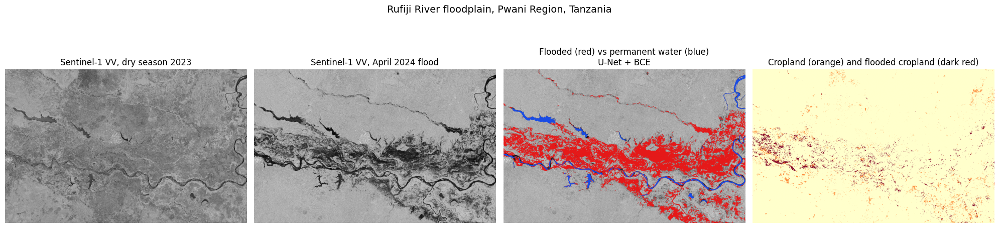

In [22]:
d = 4  # downsample for display
extent_img = np.dstack([np.clip((S1_flood[0][::d, ::d] + 25) / 25, 0, 1)] * 3)
extent_img[FLOODED[::d, ::d]] = [0.9, 0.1, 0.1]
extent_img[PERM[::d, ::d]] = [0.1, 0.3, 0.9]
fig, ax = plt.subplots(1, 4, figsize=(20, 5.5))
ax[0].imshow(S1_dry[0][::d, ::d], cmap="gray", vmin=-25, vmax=0); ax[0].set_title("Sentinel-1 VV, dry season 2023")
ax[1].imshow(S1_flood[0][::d, ::d], cmap="gray", vmin=-25, vmax=0); ax[1].set_title("Sentinel-1 VV, April 2024 flood")
ax[2].imshow(extent_img); ax[2].set_title(f"Flooded (red) vs permanent water (blue)\n{best_name}")
ax[3].imshow(np.where(FLOODED & (WC == 40), 2, np.where(WC == 40, 1, 0))[::d, ::d], cmap="YlOrRd", vmin=0, vmax=2)
ax[3].set_title("Cropland (orange) and flooded cropland (dark red)")
for a in ax: a.axis("off")
plt.suptitle("Rufiji River floodplain, Pwani Region, Tanzania", fontsize=14); plt.tight_layout(); plt.show()

In [23]:
# Save the flood map as a GeoTIFF you can open in QGIS or Google Earth Engine
from rasterio.transform import from_origin
with rasterio.open("/content/rufiji_flood_2024.tif", "w", driver="GTiff", height=FLOODED.shape[0], width=FLOODED.shape[1],
                   count=1, dtype="uint8", crs=CRS, transform=from_origin(x_min, y_max, SCALE, SCALE), compress="lzw") as f:
    f.write(FLOODED.astype(np.uint8), 1)
print("Saved /content/rufiji_flood_2024.tif")

Saved /content/rufiji_flood_2024.tif


## 15. Explainable AI: why does the model predict water, and when can we trust it?
Metrics tell us **how well** a model works. Explainable AI (XAI) tells us **why** it makes its decisions and **where we should not trust it**. This matters in disaster response, where people act on flood maps, and on a new region like Tanzania, where we have no labels to check against.

We use two methods:
1. **Permutation channel importance**: which radar input (VV, VH, VV−VH) does each model rely on?
2. **Uncertainty from test-time augmentation (TTA)**: how confident is the model, pixel by pixel? We first check on the test set that uncertainty really points to errors, then map it for the Rufiji flood.

> These cells reuse the trained models and data in memory. If your Colab runtime was restarted, run the notebook from the top again first.

### 15.1 Permutation channel importance
**Idea:** if a model relies on an input, destroying that input's information should hurt performance. For each channel we give every test chip the same channel **from a different, randomly chosen chip** (a permutation), keep the other two channels intact, and measure how much test IoU drops. Repeating 3 times gives an average and a spread.

Permuting between real chips (rather than setting the channel to zero) keeps the values realistic, so the drop reflects lost information, not strange inputs. This is the image version of permutation feature importance (Breiman, 2001).

In [24]:
best_name = max(models, key=lambda n: results[n]["test"]["IoU"])
CHANNELS = ["VV", "VH", "VV−VH"]
N_REPEATS = 3
rng = np.random.default_rng(SEED)

def test_iou(model, X):
    return evaluate(model, DataLoader(FloodDS(X, Yte), 8), Yte)["IoU"]

rows = []
for name, m in models.items():
    base = results[name]["test"]["IoU"]
    for c, ch in enumerate(CHANNELS):
        drops = []
        for _ in range(N_REPEATS):
            Xp = Xte.copy()
            Xp[:, c] = Xte[rng.permutation(len(Xte)), c]   # each chip gets another chip's channel
            drops.append(base - test_iou(m, Xp))
            del Xp
        rows.append({"Model": name, "Channel": ch, "IoU drop": np.mean(drops), "std": np.std(drops)})
        print(f"{name:38s} {ch:6s} IoU drop {np.mean(drops):.3f} ± {np.std(drops):.3f}")

imp = pd.DataFrame(rows)
display(imp.pivot(index="Model", columns="Channel", values="IoU drop")[CHANNELS].round(3))

U-Net + BCE                            VV     IoU drop 0.308 ± 0.013
U-Net + BCE                            VH     IoU drop 0.328 ± 0.007
U-Net + BCE                            VV−VH  IoU drop 0.101 ± 0.009
U-Net + weighted BCE                   VV     IoU drop 0.096 ± 0.015
U-Net + weighted BCE                   VH     IoU drop 0.362 ± 0.015
U-Net + weighted BCE                   VV−VH  IoU drop 0.030 ± 0.003
U-Net + focal+dice + oversampling      VV     IoU drop 0.222 ± 0.011
U-Net + focal+dice + oversampling      VH     IoU drop 0.515 ± 0.022
U-Net + focal+dice + oversampling      VV−VH  IoU drop 0.108 ± 0.003


Channel,VV,VH,VV−VH
Model,,,
U-Net + BCE,0.308,0.328,0.101
U-Net + focal+dice + oversampling,0.222,0.515,0.108
U-Net + weighted BCE,0.096,0.362,0.030


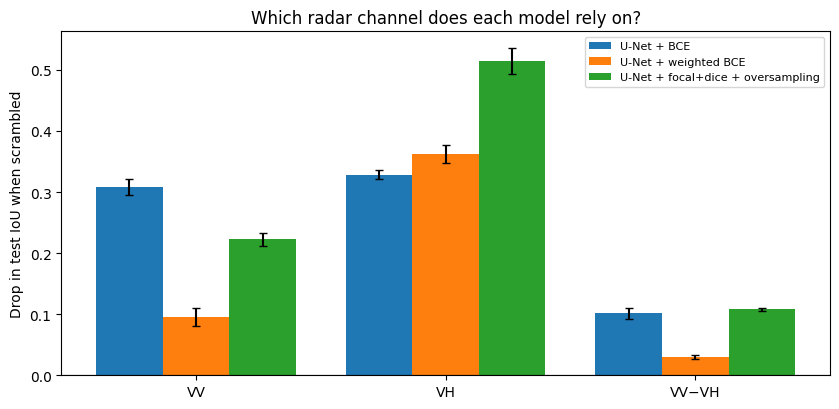

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
w = 0.8 / len(models)
for i, name in enumerate(models):
    d = imp[imp.Model == name].set_index("Channel").loc[CHANNELS]
    ax.bar(np.arange(3) + (i - (len(models) - 1) / 2) * w, d["IoU drop"], w, yerr=d["std"], capsize=3, label=name)
ax.set_xticks(np.arange(3)); ax.set_xticklabels(CHANNELS)
ax.axhline(0, c="k", lw=0.8)
ax.set_ylabel("Drop in test IoU when scrambled"); ax.set_title("Which radar channel does each model rely on?")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**How to read it.** A taller bar means the model relies more on that channel. A drop near zero means the model barely uses it, or can recover the same information from the other channels.

**Important caveat:** VV−VH is calculated from VV and VH, so the channels share information. When one is scrambled, the model can partly recover it from the other two, so these drops *underestimate* true importance. Compare channels against each other rather than reading the drops as absolute values.

**What to look for:** Otsu uses only darkness in VV. If the U-Nets also rely on VH or the VV−VH ratio, that is evidence they learned more than "dark = water", which helps explain why they beat Otsu.

### 15.2 Uncertainty from test-time augmentation
**Idea:** satellite images have no natural "up", so a good model should give the same answer for a rotated or flipped image. We feed each image in **8 orientations** (4 rotations × with/without a flip), undo the transformation on each prediction, and compare them:
- the **mean** is a slightly more robust prediction;
- the **standard deviation** measures disagreement between the 8 views. High disagreement = the model is **uncertain** about that pixel.

(A popular alternative, Monte Carlo dropout, is not possible here because this U-Net has no dropout layers. TTA is a standard substitute.)

In [26]:
def tta_predict(model, x):
    # x: (B, 3, H, W) tensor on DEVICE -> mean and std of the water probability over 8 views
    probs = []
    for k in range(4):
        for flip in (False, True):
            t = torch.rot90(x, k, (2, 3))
            if flip: t = torch.flip(t, (3,))
            with torch.autocast(DEVICE, enabled=DEVICE == "cuda"):
                p = torch.sigmoid(model(t).float())
            if flip: p = torch.flip(p, (3,))
            probs.append(torch.rot90(p, -k, (2, 3)))      # undo the rotation
    probs = torch.stack(probs)                             # (8, B, 1, H, W)
    return probs.mean(0)[:, 0], probs.std(0)[:, 0]

@torch.no_grad()
def tta_loader(model, loader):
    model.eval(); M, S = [], []
    for x, _ in loader:
        m, s = tta_predict(model, x.to(DEVICE))
        M.append(m.cpu().numpy()); S.append(s.cpu().numpy())
    return np.concatenate(M), np.concatenate(S)

best = models[best_name]
p_mean, p_std = tta_loader(best, test_loader)
print("Model:", best_name)
print(f"Test IoU without TTA: {results[best_name]['test']['IoU']:.3f}")
print(f"Test IoU with TTA:    {scores(confusion(p_mean > 0.5, Yte))['IoU']:.3f}")

Model: U-Net + BCE
Test IoU without TTA: 0.678
Test IoU with TTA:    0.681


**Does uncertainty point to errors?** An uncertainty map is only useful if the model makes more mistakes where it says it is unsure. We sort all valid test pixels into 10 equal groups from most to least confident and compute the error rate in each group. We also take the **5% least confident pixels** as "low confidence" and check what share of all errors they contain. That same threshold is used for Tanzania.

Low-confidence threshold (TTA std): 0.0516
Error rate, confident pixels:      3.44%
Error rate, low-confidence pixels: 26.21%
The 5% least confident pixels contain 28.6% of all errors.


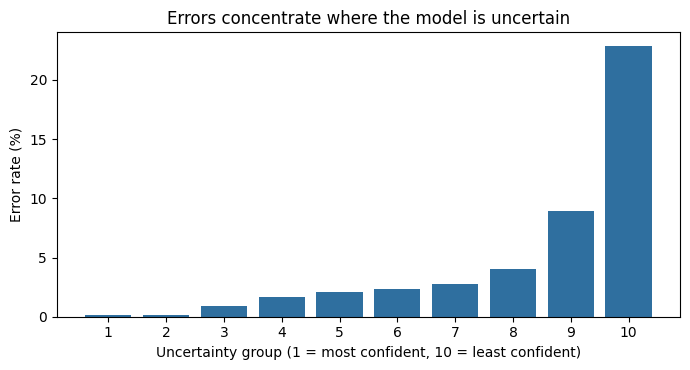

In [27]:
valid_te = Yte != -1
err = ((p_mean > 0.5) != (Yte == 1))[valid_te]
unc = p_std[valid_te]

UNC_THR = float(np.quantile(unc, 0.95))              # top 5% most uncertain pixels = "low confidence"
flag = unc >= UNC_THR
print(f"Low-confidence threshold (TTA std): {UNC_THR:.4f}")
print(f"Error rate, confident pixels:      {100*err[~flag].mean():.2f}%")
print(f"Error rate, low-confidence pixels: {100*err[flag].mean():.2f}%")
print(f"The 5% least confident pixels contain {100*err[flag].sum()/max(err.sum(),1):.1f}% of all errors.")

order = np.argsort(unc, kind="stable")
groups = np.array_split(order, 10)
err_rate = [100 * err[g].mean() for g in groups]
plt.figure(figsize=(7, 3.8))
plt.bar(range(1, 11), err_rate, color="#2f6f9f")
plt.xticks(range(1, 11)); plt.xlabel("Uncertainty group (1 = most confident, 10 = least confident)")
plt.ylabel("Error rate (%)"); plt.title("Errors concentrate where the model is uncertain")
plt.tight_layout(); plt.show()

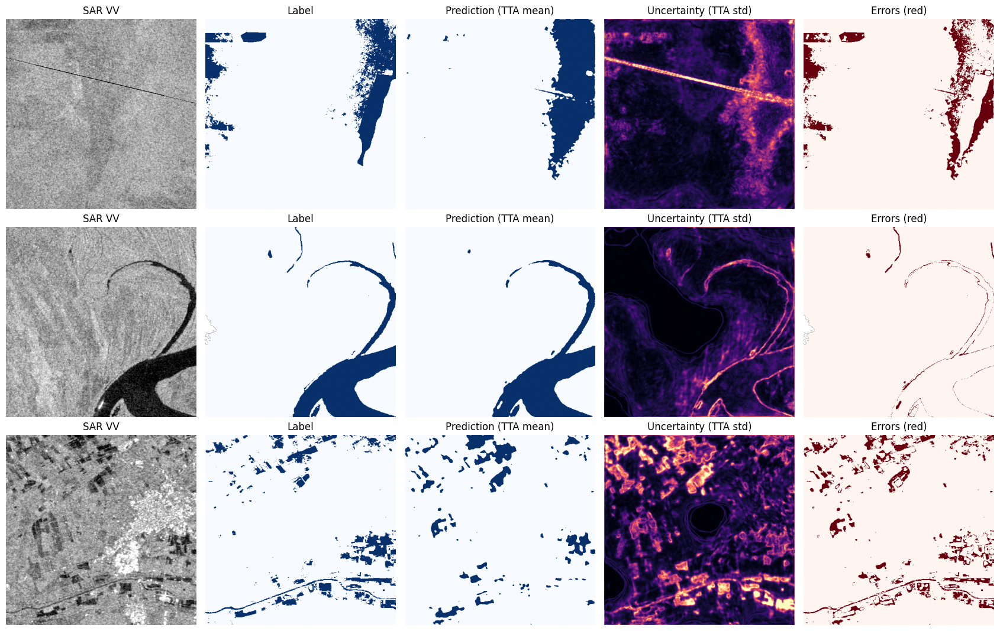

In [28]:
# Where is the model uncertain? Test examples
cand = [i for i in range(len(Yte)) if (Yte[i] == 1).mean() > 0.05]
ids = np.random.default_rng(1).choice(cand, size=min(3, len(cand)), replace=False)
fig, ax = plt.subplots(len(ids), 5, figsize=(17, 3.6 * len(ids)))
ax = np.atleast_2d(ax)
for r, i in enumerate(ids):
    lbl = np.where(Yte[i] == -1, np.nan, Yte[i])
    wrong = np.where(Yte[i] == -1, np.nan, ((p_mean[i] > 0.5) != (Yte[i] == 1)).astype(float))
    ax[r, 0].imshow(VV_te_raw[i], cmap="gray", vmin=-25, vmax=0); ax[r, 0].set_title("SAR VV")
    ax[r, 1].imshow(lbl, cmap="Blues", vmin=0, vmax=1); ax[r, 1].set_title("Label")
    ax[r, 2].imshow(p_mean[i] > 0.5, cmap="Blues"); ax[r, 2].set_title("Prediction (TTA mean)")
    im = ax[r, 3].imshow(p_std[i], cmap="magma", vmin=0, vmax=max(UNC_THR * 2, 1e-3)); ax[r, 3].set_title("Uncertainty (TTA std)")
    ax[r, 4].imshow(wrong, cmap="Reds", vmin=0, vmax=1); ax[r, 4].set_title("Errors (red)")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

**How to read it.** Bright areas in the uncertainty map should line up with the red error pixels, typically along water edges, thin channels and ambiguous dark surfaces. If they do, the uncertainty map is a trustworthy guide to where the model might be wrong, which is exactly what we need for Tanzania.

### 15.3 Uncertainty for the Rufiji flood map
In Tanzania we have no labels, so we cannot compute errors. The uncertainty map is the next best thing: it tells a decision-maker which flooded areas are **confident** and which **need checking on the ground or with other data**. A pixel counts as low confidence if either date's prediction (flood or dry season) is uncertain, using the threshold from the test set.

In [29]:
@torch.no_grad()
def tta_scene(model, x):
    model.eval(); _, H, W = x.shape
    m = np.zeros((H, W), np.float32); s = np.zeros((H, W), np.float32)
    for r in range(0, H, TILE):
        for c in range(0, W, TILE):
            t = torch.from_numpy(x[None, :, r:r+TILE, c:c+TILE]).to(DEVICE)
            a, b = tta_predict(model, t)
            m[r:r+TILE, c:c+TILE] = a[0].cpu().numpy(); s[r:r+TILE, c:c+TILE] = b[0].cpu().numpy()
    return m, s

pf_mean, pf_std = tta_scene(best, to_model_input(S1_flood))
pd_mean, pd_std = tta_scene(best, to_model_input(S1_dry))
UNC_MAP = np.maximum(pf_std, pd_std)
LOWCONF = FLOODED & (UNC_MAP >= UNC_THR)
CONF = FLOODED & ~LOWCONF

print(f"Flooded area:              {FLOODED.sum()*px_ha:,.0f} ha")
print(f"  confident:               {CONF.sum()*px_ha:,.0f} ha")
print(f"  low confidence:          {LOWCONF.sum()*px_ha:,.0f} ha ({100*LOWCONF.sum()/max(FLOODED.sum(),1):.1f}%)")

lc_unc = []
for k in np.unique(WC[FLOODED]):
    sel = FLOODED & (WC == k)
    lc_unc.append({"Land cover": WC_NAMES.get(k, str(k)), "Flooded (ha)": round(sel.sum() * px_ha),
                   "Low confidence (%)": round(100 * (sel & LOWCONF).sum() / max(sel.sum(), 1), 1),
                   "Mean uncertainty": round(float(UNC_MAP[sel].mean()), 4)})
lc_unc = pd.DataFrame(lc_unc)
display(lc_unc.sort_values("Flooded (ha)", ascending=False) if len(lc_unc) else "No flooded pixels.")

Flooded area:              35,884 ha
  confident:               28,589 ha
  low confidence:          7,296 ha (20.3%)


,Land cover,Flooded (ha),Low confidence (%),Mean uncertainty
2,Grassland,27546,17.3,0.0314
3,Cropland,3581,17.2,0.0317
0,Tree cover,2458,32.9,0.0434
6,Permanent water,1257,62.1,0.0735
7,Herbaceous wetland,713,27.6,0.0392
1,Shrubland,200,30.2,0.0408
5,Bare/sparse,119,56.8,0.0662
8,Mangroves,7,82.7,0.0824
4,Built-up,3,26.8,0.0420


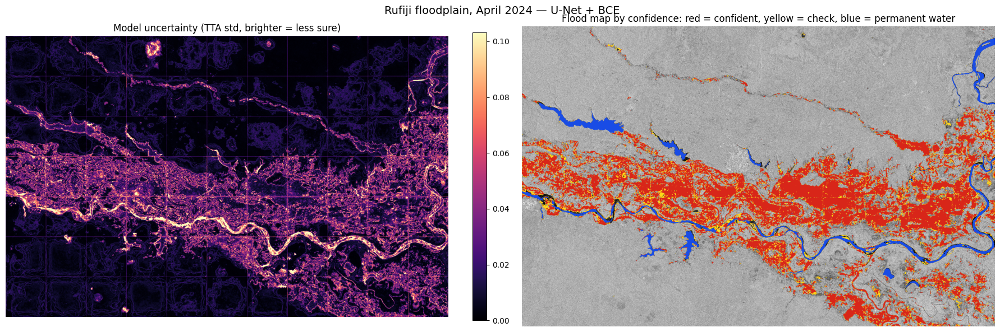

Saved /content/rufiji_uncertainty_2024.tif


In [30]:
d = 4
base = np.dstack([np.clip((S1_flood[0][::d, ::d] + 25) / 25, 0, 1)] * 3)
conf_img = base.copy()
conf_img[CONF[::d, ::d]] = [0.85, 0.15, 0.1]      # confident flood: red
conf_img[LOWCONF[::d, ::d]] = [1.0, 0.85, 0.1]    # low-confidence flood: yellow
conf_img[PERM[::d, ::d]] = [0.1, 0.3, 0.9]        # permanent water: blue
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
im = ax[0].imshow(UNC_MAP[::d, ::d], cmap="magma", vmin=0, vmax=max(UNC_THR * 2, 1e-3))
ax[0].set_title("Model uncertainty (TTA std, brighter = less sure)")
plt.colorbar(im, ax=ax[0], fraction=0.03)
ax[1].imshow(conf_img); ax[1].set_title("Flood map by confidence: red = confident, yellow = check, blue = permanent water")
for a in ax: a.axis("off")
plt.suptitle(f"Rufiji floodplain, April 2024 — {best_name}", fontsize=14); plt.tight_layout(); plt.show()

with rasterio.open("/content/rufiji_uncertainty_2024.tif", "w", driver="GTiff", height=UNC_MAP.shape[0], width=UNC_MAP.shape[1],
                   count=1, dtype="float32", crs=CRS, transform=from_origin(x_min, y_max, SCALE, SCALE), compress="lzw") as f:
    f.write(UNC_MAP.astype(np.float32), 1)
print("Saved /content/rufiji_uncertainty_2024.tif")

**How to read it.** Red areas are floods the model is sure about; yellow areas are flagged for checking. Look at *where* the yellow falls: flood edges, patchy vegetation, the delta, or particular land-cover types. The table shows whether some land-cover classes (for example grassland, which may include rice fields) are predicted less confidently than others, which supports or weakens the interpretation of the land-cover results.

**Limitation:** TTA uncertainty captures how stable a prediction is, not whether the model is systematically wrong. A model can be confidently wrong on a surface it never saw in training, such as a new soil type. Uncertainty narrows where to check; it does not replace field validation.

## 16. Discussion (fill in with your own numbers)
- **Accuracy is misleading:** every method scores high accuracy, including weak ones, because most pixels are dry. IoU/F1/recall on the water class separate the methods.
- **Imbalance handling:** compare recall of plain BCE vs weighted BCE vs focal+dice. Weighting usually raises recall (fewer missed floods) at some cost in precision (more false alarms). Which matters more for disaster response?
- **Otsu vs deep learning:** thresholding is surprisingly competitive on clear flood scenes but confuses water with other radar-dark surfaces (smooth tarmac, radar shadow in mountains, dry sand).
- **Generalisation (Bolivia):** performance on an unseen event shows whether the model learned "water" or memorised the training regions.
- **Tanzania case study:** does the model transfer to a region it never saw? Compare the flooded cropland estimate with the reported ~34,000 ha, and check where U-Net and Otsu disagree (e.g. wet rice fields, mangroves in the delta, riverbank vegetation).
- **Explainability:** which channels matter (15.1)? Do errors concentrate in uncertain pixels (15.2)? How much of the Rufiji flood is low confidence, and in which land-cover classes (15.3)?
- **Limitations:** small dataset (446 chips), hand labels come from Sentinel-2 which may disagree with SAR, single seed, no terrain data (adding elevation/HAND would reduce false positives in shadowed areas).
- **Future work:** add Sentinel-2 bands or elevation (multimodal fusion), pre/post-event change detection, geospatial foundation models (e.g. Prithvi), multiple seeds for confidence intervals.